In [43]:
from pathlib import Path
from dataclasses import dataclass
from typing import Optional
from PIL import Image
import random
import math

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.transforms import v2, functional as VF
from torchvision.io import write_png
from torchvision import tv_tensors

import pytorch_lightning as pl
from transformers import SegformerConfig, SegformerForSemanticSegmentation

from matplotlib import pyplot as plt

In [3]:
root = Path("../input/tire-sidewall/kolobok/ml/data/sidewall")

train_root = root / "train_processed"
val_root = root / "val_processed"
test_root = root / "test"
backgrounds_root = root / "backgrounds"

In [ ]:
@dataclass
class Args:
    train_root: str = str(train_root)
    val_root: str = str(val_root)
    test_root: str = str(test_root)
    test_save_dir: str = str("test_images")
    reg_backgrounds_prob: float = 0.25
    reg_backgrounds_lum: float = 0.8
    reg_backgrounds_dir: Optional[str] = str(backgrounds_root)
    segformer_model_name: str = "nvidia/segformer-b2-finetuned-ade-512-512"
    size: int = 512
    num_epochs: int = 50
    batch_size: int = 8
    num_workers: int = 4
    seed: int = 42
    eps: float = 1e-4
    lr: float = 1e-4
    gamma: float = 2.5
    focal_weight: float = 1.0
    dice_weight: float = 1.0
    iou_eps: float = 1e-4
    iou_threshold: float = 0.5

In [64]:
class UnwrapperDataset(Dataset):
    def __init__(
        self,
        root: str,
        images_name: str,
        masks_name: str,
        size: int = 512,
        do_augmentations: bool = False,
        reg_backgrounds_dir: Optional[str] = None,
        reg_backgrounds_prob: float = 0.25,
        reg_backgrounds_lum: float = 0.8,
    ):
        self.root = Path(root)
        self.images_name = images_name
        self.masks_name = masks_name
        self.size = size
        self.do_augmentations = do_augmentations
        self.reg_backgrounds_dir = reg_backgrounds_dir
        self.reg_backgrounds_prob = reg_backgrounds_prob
        self.reg_backgrounds_lum = reg_backgrounds_lum

        self.reg_backgrounds = []
        if self.reg_backgrounds_dir is not None:
            self.reg_backgrounds = list(
                map(str, Path(self.reg_backgrounds_dir).iterdir())
            )

        self.transform_img = v2.Compose(
            [
                v2.Resize(
                    (self.size, self.size),
                    interpolation=transforms.InterpolationMode.BILINEAR,
                ),
                v2.ToTensor(),
            ]
        )
        self.transform_mask = v2.Compose(
            [
                v2.Resize(
                    (self.size, self.size),
                    interpolation=transforms.InterpolationMode.NEAREST,
                ),
                v2.ToTensor(),
            ]
        )

        self.transform_aug = lambda *args: args
        if self.do_augmentations:
            self.transform_aug = v2.Compose(
                [
                    v2.RandomAffine(
                        degrees=45,
                        scale=(0.8, 1.2),
                        shear=20,
                        translate=(0.25, 0.25),
                        interpolation=transforms.InterpolationMode.BILINEAR,
                    ),
                    v2.RandomHorizontalFlip(),
                    v2.RandomVerticalFlip(),
                ]
            )

        self.data = []
        img_dir = self.root / self.images_name
        masks_dir = self.root / self.masks_name

        for image_path in img_dir.iterdir():
            image_name = image_path.name
            mask_path = masks_dir / image_name

            if image_path.exists() and mask_path.exists():
                self.data.append((str(image_path), str(mask_path)))

    def __len__(self):
        return len(self.data)

    def _resize_background(self, background: torch.Tensor, image: torch.Tensor):
        *_, h_orig, w_orig = image.shape
        *_, h_bg, w_bg = background.shape

        h_scale = h_orig / h_bg
        w_scale = w_orig / w_bg

        upscale = max(h_scale, w_scale)
        new_shape = (math.ceil(h_bg * upscale), math.ceil(w_bg * upscale))

        background = VF.resize(
            background,
            size=new_shape,
            interpolation=transforms.InterpolationMode.BICUBIC,
        )
        background = v2.RandomCrop(
            (h_orig, w_orig),
            padding_mode="constant",
            fill=0,
        )(background)
        return background

    def _apply_reg_backgrounds(self, image: torch.Tensor, mask: torch.Tensor):
        if not self.reg_backgrounds_dir or random.random() > self.reg_backgrounds_prob:
            return image, mask

        reg_background_path = random.choice(self.reg_backgrounds)
        reg_background = v2.ToTensor()(Image.open(reg_background_path)).to(image.device)
        reg_background = self._resize_background(reg_background, image)

        image = image * mask + (1 - mask) * reg_background * self.reg_backgrounds_lum

        return image, mask

    def __getitem__(self, idx: int):
        image_path, mask_path = self.data[idx]

        image_pil = Image.open(image_path)
        mask_pil = Image.open(mask_path)

        image_tensor = self.transform_img(image_pil)
        mask_tensor = self.transform_mask(mask_pil).squeeze(0)

        image_aug, mask_aug = self.transform_aug(
            tv_tensors.Image(image_tensor), tv_tensors.Mask(mask_tensor)
        )

        mask_bin = (mask_aug > 0.5).float()

        image_aug, mask_bin = self._apply_reg_backgrounds(image_aug, mask_bin)
        return image_aug, mask_bin


class TestUnwrapperDataset(Dataset):
    def __init__(
        self,
        root: str,
        size: int = 512,
    ):
        self.root = Path(root)
        self.size = size

        self.transform = v2.Compose(
            [
                v2.Resize(
                    (self.size, self.size),
                    interpolation=transforms.InterpolationMode.BILINEAR,
                ),
                v2.ToTensor(),
            ]
        )

        self.data = list(map(str, self.root.iterdir()))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int):
        image_path = self.data[idx]

        image = Image.open(image_path)

        image = self.transform(image)

        return image


In [65]:
args = Args()

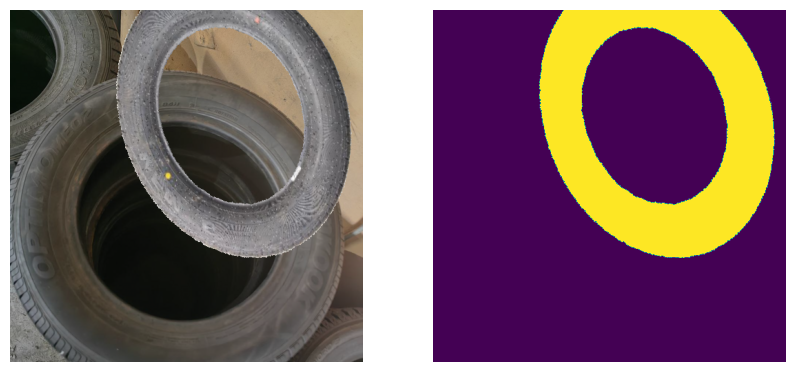

In [75]:
train_dataset = UnwrapperDataset(
    args.train_root,
    "images",
    "masks",
    do_augmentations=True,
    reg_backgrounds_dir=backgrounds_root,
    reg_backgrounds_prob=0.5,
    reg_backgrounds_lum=0.8,
)

img, mask = train_dataset[1]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img.permute(1, 2, 0))
ax[1].imshow(mask)

for i in ax:
    i.axis("off")

plt.show()

In [76]:
class Segformer(nn.Module):
    def __init__(self, args: Args):
        super().__init__()
        self.config = SegformerConfig.from_pretrained(args.segformer_model_name)
        self.config.num_labels = 1
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            args.segformer_model_name,
            config=self.config,
            ignore_mismatched_sizes=True,
        )
        self.size = [args.size, args.size]

    def _upscale_logits(self, logits: torch.Tensor):
        return VF.resize(
            logits,
            size=self.size,
            interpolation=transforms.InterpolationMode.BILINEAR,
        )

    def forward(self, images: torch.Tensor):
        logits = self.model(images).logits.squeeze(1)
        logits = self._upscale_logits(logits)
        return logits


class SegformerWrapper(pl.LightningModule):
    def __init__(self, args: Args):
        super().__init__()
        self.args = args

        self.model = Segformer(args)

    def _focal_loss(self, probs: torch.Tensor, labels: torch.Tensor):
        probs = torch.clamp(probs, min=self.args.eps, max=1 - self.args.eps)
        return torch.mean(
            -(labels * torch.log(probs) * (1 - probs) ** self.args.gamma)
            - ((1 - labels) * torch.log(1 - probs) * (probs) ** self.args.gamma)
        )

    def _dice_loss(self, probs: torch.Tensor, labels: torch.Tensor):
        labels = labels.to(probs.dtype)
        intersection = torch.sum(probs * labels, dim=(1, 2))
        union = torch.sum(probs + labels, dim=(1, 2))
        dice = (2 * intersection + self.args.eps) / (union + self.args.eps)
        return 1 - dice.mean()

    def _iou(self, probs: torch.Tensor, labels: torch.Tensor):
        preds_bin = probs > self.args.iou_threshold
        labels_bin = labels > 0.5

        intersection = (
            torch.sum(torch.logical_and(preds_bin, labels_bin), dim=(1, 2))
            + self.args.iou_eps
        )
        union = (
            torch.sum(torch.logical_or(preds_bin, labels_bin), dim=(1, 2))
            + self.args.iou_eps
        )
        return torch.mean(intersection / union)

    def loss_fn(self, logits: torch.Tensor, labels: torch.Tensor):
        probs = torch.sigmoid(logits)
        focal_loss = self.args.focal_weight * self._focal_loss(probs, labels)
        dice_loss = self.args.dice_weight * self._dice_loss(probs, labels)

        total_loss = focal_loss + dice_loss
        return total_loss, focal_loss, dice_loss

    def forward(self, images: torch.Tensor):
        logits = self.model(images)
        return logits

    def training_step(self, batch, batch_idx):
        images, masks = batch
        images = images.float()
        masks = masks.float()

        logits = self(images)

        total_loss, focal_loss, dice_loss = self.loss_fn(logits, masks)

        self.log("train_loss", total_loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log(
            "train_focal_loss", focal_loss, on_step=True, on_epoch=True, prog_bar=True
        )
        self.log(
            "train_dice_loss", dice_loss, on_step=True, on_epoch=True, prog_bar=True
        )
        return total_loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        images = images.float()
        masks = masks.float()

        logits = self(images)

        total_loss, focal_loss, dice_loss = self.loss_fn(logits, masks)

        probs = torch.sigmoid(logits)
        iou = self._iou(probs, masks)

        self.log("val_loss", total_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(
            "val_focal_loss", focal_loss, on_step=False, on_epoch=True, prog_bar=True
        )
        self.log(
            "val_dice_loss", dice_loss, on_step=False, on_epoch=True, prog_bar=True
        )
        self.log("val_iou", iou, on_step=False, on_epoch=True, prog_bar=True)

        return {"val_loss": total_loss, "val_iou": iou}

    def on_validation_epoch_end(self):
        if (
            hasattr(self.trainer, "test_dataloader")
            and self.trainer.test_dataloader is not None
        ):
            test_loader = self.trainer.test_dataloader()

            self.eval()

            with torch.no_grad():
                for batch_idx, batch in enumerate(test_loader):
                    images = batch
                    images = images.to(self.device).float()

                    logits = self(images)
                    probs = torch.sigmoid(logits)

                    masks = (probs > self.args.iou_threshold).float()

                    for i, (image, mask) in enumerate(zip(images, masks)):
                        masked_image = image * mask.unsqueeze(0)

                        masked_image_uint8 = (masked_image * 255).clamp(0, 255).byte()

                        epoch_num = self.current_epoch
                        save_path = (
                            Path(self.args.test_save_dir)
                            / f"epoch_{epoch_num:03d}"
                            / f"masked_{batch_idx}_{i}.png"
                        )
                        save_path.parent.mkdir(parents=True, exist_ok=True)
                        write_png(masked_image_uint8.cpu(), str(save_path))

            self.train()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.args.lr)
        return optimizer


In [ ]:
def main():
    pl.seed_everything(args.seed)

    train_dataset = UnwrapperDataset(
        root=args.train_root,
        images_name="images",
        masks_name="masks",
        size=args.size,
        do_augmentations=True,
        reg_backgrounds_dir=args.reg_backgrounds_dir,
        reg_backgrounds_prob=args.reg_backgrounds_prob,
        reg_backgrounds_lum=args.reg_backgrounds_lum,
    )

    val_dataset = UnwrapperDataset(
        root=args.val_root,
        images_name="images",
        masks_name="masks",
        size=args.size,
        do_augmentations=False,
        reg_backgrounds_prob=0,
    )

    test_dataset = TestUnwrapperDataset(root=args.test_root, size=args.size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True,
    )

    model = SegformerWrapper(args)

    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        dirpath="lightning_logs/checkpoints",
        filename="segformer-{epoch:03d}-{val_iou:.5f}",
        monitor="val_iou",
        mode="max",
        save_top_k=3,
        save_last=True,
    )

    trainer = pl.Trainer(
        max_epochs=args.num_epochs,
        callbacks=[checkpoint_callback],
        log_every_n_steps=10,
        check_val_every_n_epoch=1,
        enable_progress_bar=True,
        enable_model_summary=True,
    )

    trainer.test_dataloader = lambda: test_loader

    print("Starting training...")
    trainer.fit(model, train_loader, val_loader)
    print(f"Masked images saved to: {args.test_save_dir}")


if __name__ == "__main__":
    main()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([1, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training...


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

NameError: name 'exit' is not defined